# UMAP + HDBSCAN Clustering — Mean-Pooled Playlist Embeddings

**Approach:**
- UMAP reduces pre-computed mean-pooled playlist embeddings to low-dimensional Euclidean space
- HDBSCAN clusters in UMAP space

**Pipeline:**
1. Load `mean_pooled_embeddings.pkl` (same file used by FKM notebook)
2. UMAP on playlist embeddings — test 10, 15, 20 dimensions
3. Visualize UMAP layout (2D)
4. HDBSCAN clustering + parameter tuning
5. Prune overly broad clusters via LSH (`lsh_cluster_picking`)
6. t-SNE visualization of pruned clusters

**This code was run in Colab, as a CPU with high RAM is needed to keep all the data in memory and operate on it simultaneously**


# Setup

In [1]:
from google.colab import drive
import os
drive.mount('/content/drive')

DRIVE_BASE           = "/content/drive/MyDrive/S2026/Spotify Playlist Data/Processed Data/calced_embeddings"
PROJECT_BASE         = "/content/drive/MyDrive/S2026/CS 274/Playlist-Recommender"
EMBEDDINGS_PKL       = f"{DRIVE_BASE}/mean_pooled_embeddings.pkl"
CLUSTERS_OUTPUT_DIR  = f"{PROJECT_BASE}/umap clusters"
REPO_DIR             = "/content/RecsysUpgrade"

os.makedirs(CLUSTERS_OUTPUT_DIR, exist_ok=True)
print("Paths configured.")


Mounted at /content/drive
Paths configured.


In [2]:
if not os.path.exists(REPO_DIR):
    !git clone https://github.com/siddmohanty111/RecsysUpgrade.git {REPO_DIR}
else:
    !git -C {REPO_DIR} pull

print("Repo ready:", REPO_DIR)

Cloning into '/content/RecsysUpgrade'...
remote: Enumerating objects: 127, done.
remote: Counting objects: 100% (127/127), done.
remote: Compressing objects: 100% (98/98), done.
Receiving objects: 100% (127/127), 2.03 MiB | 20.60 MiB/s, done.
remote: Total 127 (delta 63), reused 79 (delta 28), pack-reused 0 (from 0)
Resolving deltas: 100% (63/63), done.
Repo ready: /content/RecsysUpgrade


In [3]:
%pip install -r {REPO_DIR}/requirements.txt
%pip install umap-learn hdbscan -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 59.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 832.6/832.6 kB 34.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 38.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 548.1/548.1 kB 24.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 2.9 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
  Attempting uninstall: langchain-core
    Found existing installation: langchain-core 1.3.1
    Uninstalling langchain-core-1.3.1:
      Successfully uninstalled langchain-core-1.3.1
ERROR: pip's dependenc

In [4]:
import importlib.util

spec = importlib.util.spec_from_file_location(
    "lsh_cluster_picking",
    os.path.join(REPO_DIR, "PlaylistRecsysUpgrade", "clustering", "lsh_cluster_picking.py"),
)
lsh_cluster_picking = importlib.util.module_from_spec(spec)
spec.loader.exec_module(lsh_cluster_picking)

print("lsh_cluster_picking loaded.")


lsh_cluster_picking loaded.


# Imports

In [5]:
import os
import pickle
import importlib.util

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import umap
import hdbscan
from sklearn.manifold import TSNE


# Load Embeddings

In [6]:
with open(EMBEDDINGS_PKL, 'rb') as f:
    data = pickle.load(f)

# Support both a raw dict (pid -> vector) and the structured dict used by other pipeline scripts
if isinstance(data, dict) and 'playlist_embeddings' in data:
    playlist_embeddings = data['playlist_embeddings']
    playlist_titles     = data.get('playlist_titles', {})
    playlist_tracks     = data.get('playlist_tracks', {})
else:
    playlist_embeddings = data
    playlist_titles     = {}
    playlist_tracks     = {}

embedding_matrix = np.array(list(playlist_embeddings.values()))
pids = list(playlist_embeddings.keys())

print(f"Loaded {len(pids)} playlists, embedding dim = {embedding_matrix.shape[1]}")


Loaded 1000001 playlists, embedding dim = 768


# UMAP — Mean-Pooled Playlist Embeddings

Fit UMAP on a 100k subsample of playlist embeddings, then batch-transform the full dataset.
We test three dimensionalities (10, 15, 20). They all perform similarly, so I picked 15.


In [7]:
UMAP_FIT_SAMPLE = 100_000
TRANSFORM_BATCH = 10_000
UMAP_DIMS_TO_TRY = [10, 15, 20]
UMAP_DIM_DEFAULT = 15   # used downstream for clustering

rng = np.random.default_rng(42)

n_total = len(pids)
print(f"Total playlists: {n_total:,}, embedding dim: {embedding_matrix.shape[1]}")

# Subsample for fitting
fit_idx = rng.choice(n_total, size=min(UMAP_FIT_SAMPLE, n_total), replace=False)
fit_data = embedding_matrix[fit_idx]
print(f"Fitting UMAP on {len(fit_idx):,} samples")

umap_results = {}   # dim -> (n_total, dim) array

for n_components in UMAP_DIMS_TO_TRY:
    print(f"\n── UMAP {n_components}d ──")
    reducer = umap.UMAP(
        n_components=n_components,
        n_neighbors=15,
        min_dist=0.0,
        metric='cosine',
        low_memory=True,
        random_state=42,
        verbose=False,
    )
    reducer.fit(fit_data)
    print(f"  Fit complete. Transforming {n_total:,} points in batches...")

    parts = []
    for start in range(0, n_total, TRANSFORM_BATCH):
        batch = embedding_matrix[start : start + TRANSFORM_BATCH]
        parts.append(reducer.transform(batch))
        print(f"  {min(start + TRANSFORM_BATCH, n_total):,} / {n_total:,}", end="\r")
    print()

    umap_results[n_components] = np.vstack(parts)
    print(f"  Done. Output shape: {umap_results[n_components].shape}")

print("\nAll UMAP reductions complete.")


Total playlists: 1,000,001, embedding dim: 768
Fitting UMAP on 100,000 samples

── UMAP 10d ──


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  Fit complete. Transforming 1,000,001 points in batches...
  1,000,001 / 1,000,001
  Done. Output shape: (1000001, 10)

── UMAP 15d ──


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  Fit complete. Transforming 1,000,001 points in batches...
  1,000,001 / 1,000,001
  Done. Output shape: (1000001, 15)

── UMAP 20d ──


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  Fit complete. Transforming 1,000,001 points in batches...
  1,000,001 / 1,000,001
  Done. Output shape: (1000001, 20)

All UMAP reductions complete.


This takes roughly 2 hours

# UMAP Dimension Selection Metrics

Three metrics help choose the best number of UMAP dimensions:

| Metric | What it measures | Want |
|---|---|---|
| **Trustworthiness** | Fraction of each point's true near-neighbours that are also near in UMAP space | High (→1) |
| **Continuity** | Fraction of UMAP near-neighbours that were also near in original space | High (→1) |
| **HDBSCAN noise fraction** | Fraction of points labelled as noise (−1) at a fixed `min_cluster_size` | Low |

Trustworthiness + continuity together form the **co-ranking** framework.
Higher is better for both. A large drop in either as dims decrease means that
dimensionality is too low to preserve neighbourhood structure faithfully.

In [8]:
from sklearn.manifold import trustworthiness

# Run metrics on a small eval sample to keep it fast
EVAL_N = 5_000
eval_idx = rng.choice(n_total, size=EVAL_N, replace=False)

original_sample = embedding_matrix[eval_idx]

rows = []
for dim, embedding in umap_results.items():
    umap_sample = embedding[eval_idx]

    tw = trustworthiness(original_sample, umap_sample, n_neighbors=15, metric='cosine')
    cont = trustworthiness(umap_sample, original_sample, n_neighbors=15, metric='euclidean')

    # Quick HDBSCAN probe
    probe = hdbscan.HDBSCAN(min_cluster_size=50, core_dist_n_jobs=-1)
    probe_labels = probe.fit_predict(umap_sample)
    noise_frac = (probe_labels == -1).mean()

    rows.append({
        'UMAP dims': dim,
        'Trustworthiness': round(tw, 4),
        'Continuity': round(cont, 4),
        'HDBSCAN noise %': round(noise_frac * 100, 2),
    })
    print(f"  {dim}d: trust={tw:.4f}  cont={cont:.4f}  noise={noise_frac:.2%}")

metrics_df = pd.DataFrame(rows).set_index('UMAP dims')
display(metrics_df)
print(f"\nDefault selected: {UMAP_DIM_DEFAULT}d  (change UMAP_DIM_DEFAULT above to override)")


  10d: trust=0.8339  cont=0.9425  noise=2.14%
  15d: trust=0.8332  cont=0.9420  noise=2.00%
  20d: trust=0.8331  cont=0.9420  noise=2.12%


,Trustworthiness,Continuity,HDBSCAN noise %
UMAP dims,,,
10,0.8339,0.9425,2.14
15,0.8332,0.9420,2.00
20,0.8331,0.9420,2.12



Default selected: 15d  (change UMAP_DIM_DEFAULT above to override)


# Visualize UMAP Layout (2D projection for plotting)

I run a separate 2D UMAP purely for visualization — the clustering uses
`UMAP_DIM_DEFAULT` dimensions, not 2.

Fitting 2D UMAP for visualization...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  2D layout shape: (20000, 2)


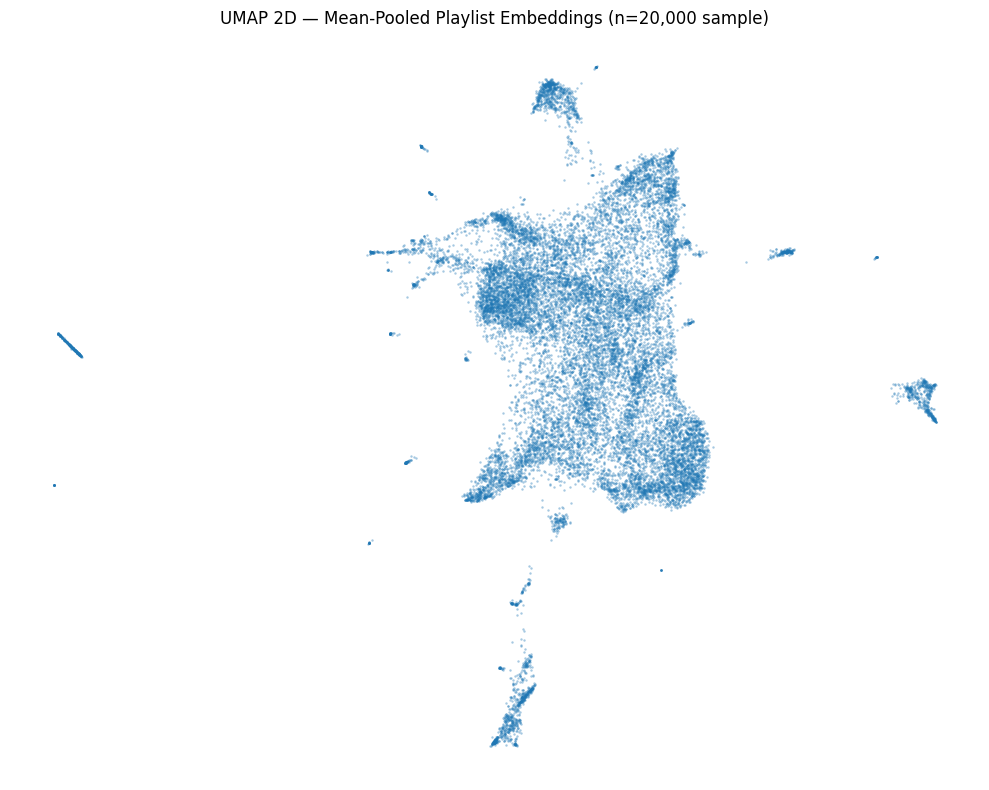

In [9]:
VIZ_SAMPLE = 20_000
viz_idx = rng.choice(n_total, size=VIZ_SAMPLE, replace=False)

print("Fitting 2D UMAP for visualization...")
reducer_2d = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,   # slightly higher for cleaner scatter
    metric='cosine',
    low_memory=True,
    random_state=42,
    verbose=False,
)
umap_2d = reducer_2d.fit_transform(embedding_matrix[viz_idx])
print(f"  2D layout shape: {umap_2d.shape}")

plt.figure(figsize=(10, 8))
plt.scatter(umap_2d[:, 0], umap_2d[:, 1], s=3, alpha=0.4, linewidths=0)
plt.title(f"UMAP 2D — Mean-Pooled Playlist Embeddings (n={VIZ_SAMPLE:,} sample)")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.axis('off')
plt.tight_layout()
plt.show()


# HDBSCAN Clustering on Track Embeddings

HDBSCAN is density-based: it finds clusters of arbitrary shape and marks low-density
points as noise (label `−1`). `min_cluster_size` is the primary knob — larger values
produce fewer, bigger clusters.

Note: `cluster_selection_method='eom'` (excess of mass) tends to produce more
clusters of varying size. Use `'leaf'` for more uniform cluster sizes.

In [17]:
embedding_for_clustering = umap_results[UMAP_DIM_DEFAULT]

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=200,
    min_samples=10,
    cluster_selection_method='eom',
    core_dist_n_jobs=-1,
    prediction_data=True,           # needed for soft cluster membership if wanted later
)
print(f"Running HDBSCAN on {embedding_for_clustering.shape} embedding...")
cluster_labels = clusterer.fit_predict(embedding_for_clustering)

n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
noise_frac  = (cluster_labels == -1).mean()
print(f"  Clusters found:  {n_clusters}")
print(f"  Noise points:    {noise_frac:.2%} of dataset")

# Build cluster assignment DataFrame aligned with pids
cluster_assignments_df = pd.DataFrame({
    'pid': pids,
    'cluster': cluster_labels,
})

# Save initial (pre-tuned) cluster assignments and labels
initial_cluster_labels = cluster_labels.copy()
initial_cluster_assignments_df = cluster_assignments_df.copy()

# Summary table
cluster_sizes = (
    cluster_assignments_df[cluster_assignments_df['cluster'] != -1]
    .groupby('cluster')
    .size()
    .rename('playlist_count')
    .sort_values(ascending=False)
    .reset_index()
)
print(f"\nCluster size summary (top 15):")
display(cluster_sizes.head(15))

Running HDBSCAN on (1000001, 15) embedding...
  Clusters found:  133
  Noise points:    66.02% of dataset

Cluster size summary (top 15):


,cluster,playlist_count
0,96,62127
1,36,33155
2,12,31395
3,29,19845
4,119,17232
5,26,14244
6,109,11917
7,122,10809
8,87,8916
9,61,8809


# HDBSCAN Parameter Tuning

Grid search over `min_cluster_size` ∈ {100, 200, 500, 1000} and
`cluster_selection_epsilon` ∈ [0, 2×UMAP_DIM_DEFAULT] in steps of 5.

**Selection criterion:** HDBSCAN's built-in `relative_validity_` score (a DBCV-based
relative validity index — higher is better). The best configuration is then used to
overwrite `cluster_labels` and `data['track_cluster']` for all downstream cells.

Grid search: 4 min_cluster_size × 7 epsilon = 28 runs
  min_cluster_size values : [100, 200, 500, 1000]
  epsilon values          : [0, 5, 10, 15, 20, 25, 30]

  [  1/28]  mcs=  100  eps=  0.0  clusters= 227  noise=70.94%  rel_val=0.1083
  [  2/28]  mcs=  100  eps=  5.0  clusters=  12  noise=0.01%  rel_val=0.1785
  [  3/28]  mcs=  100  eps= 10.0  clusters=   3  noise=0.01%  rel_val=0.1831
  [  4/28]  mcs=  100  eps= 15.0  clusters=   2  noise=0.01%  rel_val=0.0924
  [  5/28]  mcs=  100  eps= 20.0  clusters=   2  noise=0.01%  rel_val=0.0924
  [  6/28]  mcs=  100  eps= 25.0  clusters=   2  noise=0.01%  rel_val=0.0924
  [  7/28]  mcs=  100  eps= 30.0  clusters=   2  noise=0.01%  rel_val=0.0924
  [  8/28]  mcs=  200  eps=  0.0  clusters= 133  noise=66.02%  rel_val=0.1025
  [  9/28]  mcs=  200  eps=  5.0  clusters=   9  noise=0.07%  rel_val=0.1780
  [ 10/28]  mcs=  200  eps= 10.0  clusters=   2  noise=0.01%  rel_val=0.0924
  [ 11/28]  mcs=  200  eps= 15.0  clusters=   2  noise=0.01%  rel_va

,min_cluster_size,cluster_selection_epsilon,n_clusters,noise_frac,relative_validity
0,100,10,3,0.0001,0.1831
1,100,5,12,0.0001,0.1785
2,200,5,9,0.0007,0.1780
3,500,5,5,0.0020,0.1769
4,1000,5,4,0.0029,0.1761
5,500,0,83,0.6912,0.1280
6,100,0,227,0.7094,0.1083
7,200,0,133,0.6602,0.1025
8,100,30,2,0.0001,0.0924
9,100,15,2,0.0001,0.0924



Best configuration  →  min_cluster_size=100  cluster_selection_epsilon=10.0  (rel_val=0.1831)
  Clusters found : 3
  Noise points   : 0.01% of dataset

Cluster size summary (top 15):


,cluster,playlist_count
0,2,999382
1,0,371
2,1,173


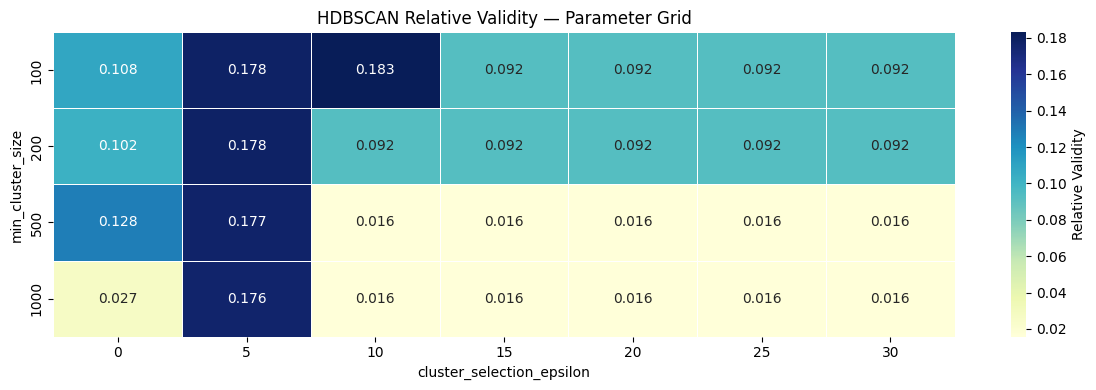

In [12]:
from itertools import product as _product

MIN_CLUSTER_SIZES   = [100, 200, 500, 1000]
EPSILON_STEP        = 5
epsilon_max         = 2 * UMAP_DIM_DEFAULT                        # 30 when default is 15
EPSILONS            = [round(e * EPSILON_STEP, 1)
                       for e in range(int(epsilon_max / EPSILON_STEP) + 1)]   # [0, 5, 10, ..., 30]

embedding_for_clustering = umap_results[UMAP_DIM_DEFAULT]
total_runs = len(MIN_CLUSTER_SIZES) * len(EPSILONS)

print(f"Grid search: {len(MIN_CLUSTER_SIZES)} min_cluster_size × {len(EPSILONS)} epsilon "
      f"= {total_runs} runs")
print(f"  min_cluster_size values : {MIN_CLUSTER_SIZES}")
print(f"  epsilon values          : {EPSILONS}\n")

tuning_results = []

for i, (mcs, eps) in enumerate(_product(MIN_CLUSTER_SIZES, EPSILONS), 1):
    _c = hdbscan.HDBSCAN(
        min_cluster_size=mcs,
        min_samples=10,
        cluster_selection_method='eom',
        cluster_selection_epsilon=eps,
        core_dist_n_jobs=-1,
        gen_min_span_tree=True, # Added to ensure relative_validity_ is available
    )
    _labels = _c.fit_predict(embedding_for_clustering)
    _n      = len(set(_labels)) - (1 if -1 in _labels else 0)
    _noise  = (_labels == -1).mean()
    _rv     = float(_c.relative_validity_)

    tuning_results.append({
        'min_cluster_size'          : mcs,
        'cluster_selection_epsilon' : eps,
        'n_clusters'                : _n,
        'noise_frac'                : round(_noise, 4),
        'relative_validity'         : round(_rv, 4),
    })
    print(f"  [{i:3d}/{total_runs}]  mcs={mcs:5d}  eps={eps:5.1f}  "
          f"clusters={_n:4d}  noise={_noise:.2%}  rel_val={_rv:.4f}")

tuning_df = pd.DataFrame(tuning_results)

print("\n── Full results (sorted by relative validity) ──")
display(tuning_df.sort_values('relative_validity', ascending=False).reset_index(drop=True))

# ── Best configuration ──────────────────────────────────────────────────────
best_row = tuning_df.loc[tuning_df['relative_validity'].idxmax()]
best_mcs = int(best_row['min_cluster_size'])
best_eps = float(best_row['cluster_selection_epsilon'])

print(f"\nBest configuration  →  min_cluster_size={best_mcs}  "
      f"cluster_selection_epsilon={best_eps}  "
      f"(rel_val={best_row['relative_validity']:.4f})")

# Re-fit with best params (add prediction_data for downstream soft-membership use)
best_clusterer = hdbscan.HDBSCAN(
    min_cluster_size=best_mcs,
    min_samples=10,
    cluster_selection_method='eom',
    cluster_selection_epsilon=best_eps,
    core_dist_n_jobs=-1,
    prediction_data=True,
    gen_min_span_tree=True, # Added to ensure relative_validity_ is available
)
cluster_labels          = best_clusterer.fit_predict(embedding_for_clustering)
n_clusters              = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
noise_frac              = (cluster_labels == -1).mean()

print(f"  Clusters found : {n_clusters}")
print(f"  Noise points   : {noise_frac:.2%} of dataset")

# Update cluster assignments DataFrame so all downstream cells stay consistent
cluster_assignments_df = pd.DataFrame({
    'pid': pids,
    'cluster': cluster_labels,
})

cluster_sizes = (
    cluster_assignments_df[cluster_assignments_df['cluster'] != -1]
    .groupby('cluster')
    .size()
    .rename('playlist_count')
    .sort_values(ascending=False)
    .reset_index()
)
print(f"\nCluster size summary (top 15):")
display(cluster_sizes.head(15))

# ── Heatmap: relative validity across the grid ──────────────────────────────
pivot = tuning_df.pivot(
    index='min_cluster_size',
    columns='cluster_selection_epsilon',
    values='relative_validity',
)
plt.figure(figsize=(12, 4))
sns.heatmap(
    pivot,
    annot=True, fmt='.3f', cmap='YlGnBu',
    linewidths=0.5, linecolor='white',
    cbar_kws={'label': 'Relative Validity'},
)
plt.title('HDBSCAN Relative Validity — Parameter Grid')
plt.xlabel('cluster_selection_epsilon')
plt.ylabel('min_cluster_size')
plt.tight_layout()
plt.show()

The grid search actually did not show decent results, likely because the parameter bounds for the grid search were bad. I stick to the default HDBSCAN parameters moving forward as they reveal more about the true cluster structure of this dataset. Tuning takes about 1 hour.

# Cluster Pruning

Perform LSH on each cluster to identify overly broad clusters and remove them.
A cluster is pruned if its largest LSH sub-bucket contains ≤ 2% of the playlists
in that cluster — meaning no meaningful sub-group of similar playlists dominates it.

Noise points (cluster = −1) from HDBSCAN are excluded before pruning.


In [18]:
# Reload lsh_cluster_picking if not already in scope (e.g. when skipping earlier cells)
try:
    lsh_cluster_picking
except NameError:
    try:
        REPO_DIR
    except NameError:
        REPO_DIR = "/content/RecsysUpgrade"
    spec = importlib.util.spec_from_file_location(
        "lsh_cluster_picking",
        os.path.join(REPO_DIR, "PlaylistRecsysUpgrade", "clustering", "lsh_cluster_picking.py"),
    )
    lsh_cluster_picking = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(lsh_cluster_picking)
    print("lsh_cluster_picking loaded.")

# Exclude HDBSCAN noise points from the initial (pre-tuned) cluster assignments before pruning
non_noise_mask = initial_cluster_assignments_df['cluster'] != -1
cluster_assignments_no_noise = initial_cluster_assignments_df[non_noise_mask].reset_index(drop=True)

# Row-align embeddings to match the non-noise cluster assignments
pid_to_idx = {pid: i for i, pid in enumerate(pids)}
non_noise_row_indices = np.array([pid_to_idx[pid] for pid in cluster_assignments_no_noise['pid']])
non_noise_embeddings  = embedding_matrix[non_noise_row_indices]

NUM_CLUSTERS_BEFORE = cluster_assignments_no_noise['cluster'].nunique()

kept_clusters, kept_pids = lsh_cluster_picking.prune_clusters(
    non_noise_embeddings,
    cluster_assignments_no_noise,
    threshold_percent=0.02,
)

print(f"\nClusters kept  : {len(kept_clusters)} / {NUM_CLUSTERS_BEFORE}")
print(f"Playlists kept : {len(kept_pids)}")

# Persist pruned assignments
pruned_df = cluster_assignments_no_noise[cluster_assignments_no_noise['cluster'].isin(kept_clusters)]
pruned_output = os.path.join(CLUSTERS_OUTPUT_DIR, "hdbscan_clusters_pruned_initial.csv") # Changed output file name
pruned_df.to_csv(pruned_output, index=False)
print(f"Pruned cluster assignments saved to {pruned_output}")

Keeping cluster 0 (Max Bucket: 41.51% of playlists). 371 playlists in cluster.
Keeping cluster 1 (Max Bucket: 22.59% of playlists). 270 playlists in cluster.
Keeping cluster 2 (Max Bucket: 3.96% of playlists). 1717 playlists in cluster.
Keeping cluster 3 (Max Bucket: 2.60% of playlists). 231 playlists in cluster.
Keeping cluster 4 (Max Bucket: 40.29% of playlists). 417 playlists in cluster.
Keeping cluster 5 (Max Bucket: 3.99% of playlists). 1831 playlists in cluster.
Keeping cluster 6 (Max Bucket: 4.55% of playlists). 1033 playlists in cluster.
Keeping cluster 7 (Max Bucket: 3.39% of playlists). 560 playlists in cluster.
Keeping cluster 8 (Max Bucket: 9.51% of playlists). 694 playlists in cluster.
Keeping cluster 9 (Max Bucket: 4.73% of playlists). 1312 playlists in cluster.
Keeping cluster 10 (Max Bucket: 9.63% of playlists). 519 playlists in cluster.
Keeping cluster 11 (Max Bucket: 5.45% of playlists). 422 playlists in cluster.
Keeping cluster 12 (Max Bucket: 8.09% of playlists). 31

# t-SNE on Pruned Clusters


Running t-SNE on 544 playlists from 2 pruned clusters...
t-SNE complete.


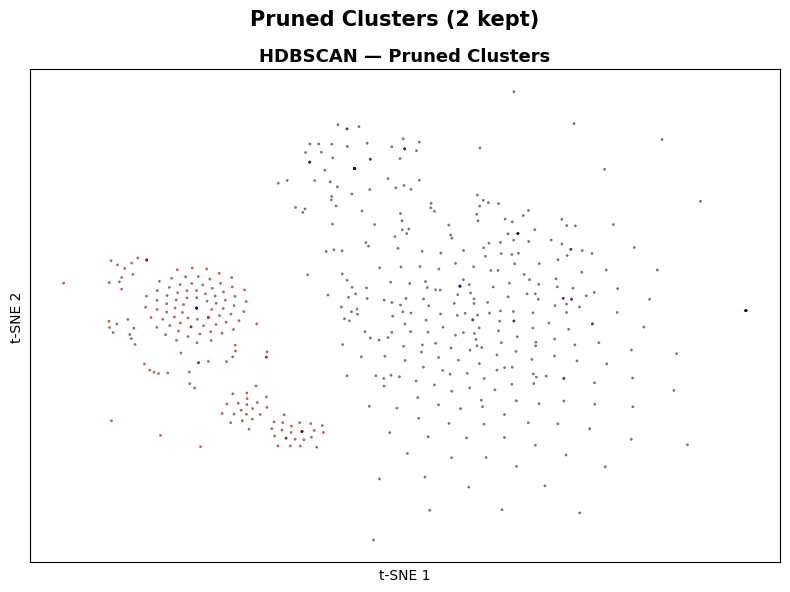

Plot saved.


In [14]:
pid_to_idx = {pid: i for i, pid in enumerate(pids)}

pruned_pids_list   = pruned_df['pid'].tolist()
pruned_labels      = pruned_df['cluster'].values
pruned_row_indices = np.array([pid_to_idx[pid] for pid in pruned_pids_list])
pruned_embeddings  = embedding_matrix[pruned_row_indices]

# Sub-sample for t-SNE if the pruned set is large
TSNE_PRUNED_SAMPLE = min(20_000, len(pruned_pids_list))
rng_tsne = np.random.default_rng(42)
tsne_pruned_idx    = rng_tsne.choice(len(pruned_pids_list), size=TSNE_PRUNED_SAMPLE, replace=False)

pruned_tsne_input  = pruned_embeddings[tsne_pruned_idx]
pruned_tsne_labels = pruned_labels[tsne_pruned_idx]

print(f"Running t-SNE on {TSNE_PRUNED_SAMPLE} playlists from {len(kept_clusters)} pruned clusters...")
tsne_pruned = TSNE(n_components=2, perplexity=30, random_state=42, n_jobs=-1)
pruned_tsne_coords = tsne_pruned.fit_transform(pruned_tsne_input)
print("t-SNE complete.")

# --- Plot ---
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(
    pruned_tsne_coords[:, 0], pruned_tsne_coords[:, 1],
    c=pruned_tsne_labels, cmap="turbo", s=4, alpha=0.6, linewidths=0,
)
ax.set_title("HDBSCAN — Pruned Clusters", fontsize=13, fontweight="bold")
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.set_xticks([])
ax.set_yticks([])
fig.suptitle(f"Pruned Clusters ({len(kept_clusters)} kept)", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(CLUSTERS_OUTPUT_DIR, "hdbscan_pruned_clusters_tsne.png"), dpi=150)
plt.show()
print("Plot saved.")


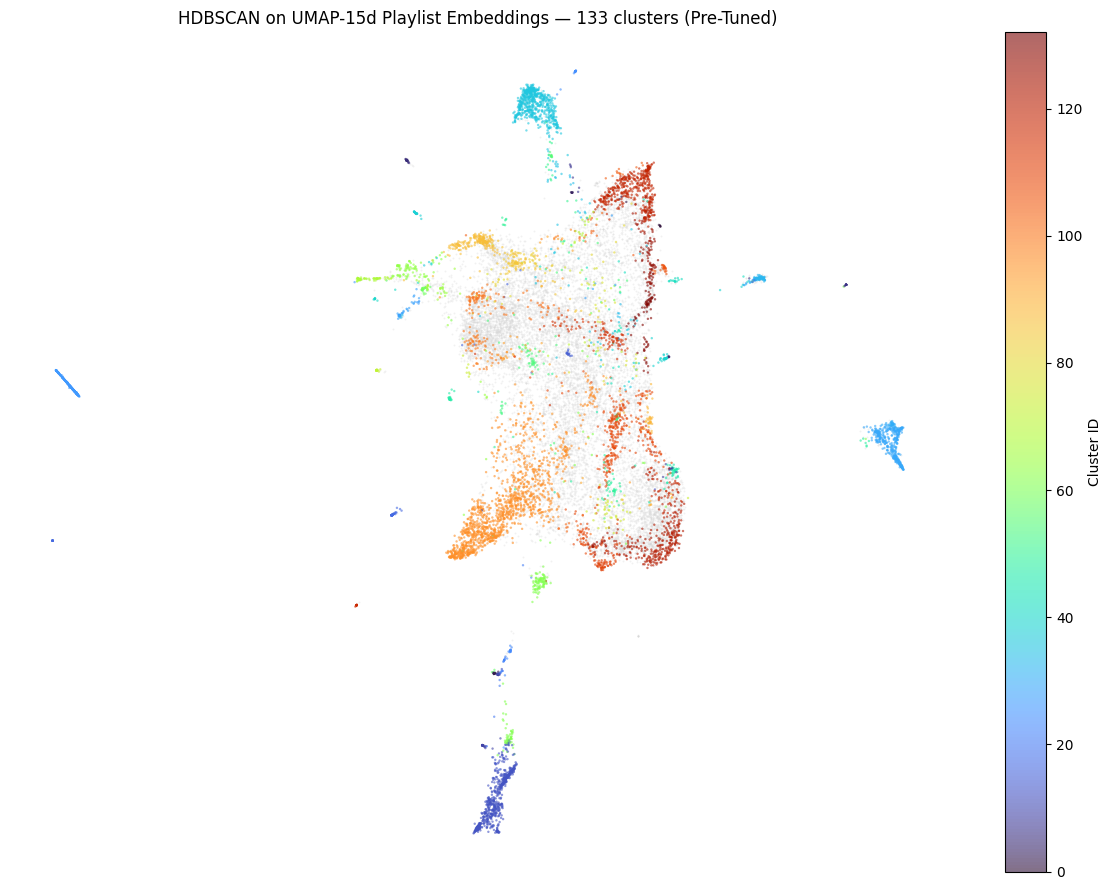

In [19]:
# Visualize clusters on the 2D layout
# Map the viz sample's cluster labels for colouring
viz_labels = initial_cluster_labels[viz_idx]
noise_mask   = viz_labels == -1
cluster_mask = ~noise_mask

plt.figure(figsize=(12, 9))
plt.scatter(
    umap_2d[noise_mask, 0], umap_2d[noise_mask, 1],
    s=2, c='lightgrey', alpha=0.3, linewidths=0, label='Noise'
)
sc = plt.scatter(
    umap_2d[cluster_mask, 0], umap_2d[cluster_mask, 1],
    s=3, c=viz_labels[cluster_mask], cmap='turbo', alpha=0.6, linewidths=0
)
plt.colorbar(sc, label='Cluster ID')
plt.title(f"HDBSCAN on UMAP-{UMAP_DIM_DEFAULT}d Playlist Embeddings — {n_clusters} clusters (Pre-Tuned)")
plt.axis('off')
plt.tight_layout()
plt.show()

### Save Data
Save the clustered dataframe and the UMAP embeddings to disk for later use.

In [20]:
output_path_data = os.path.join(CLUSTERS_OUTPUT_DIR, "hdbscan_clusters.csv")
output_path_umap = os.path.join(CLUSTERS_OUTPUT_DIR, "umap_results.pkl")
output_path_initial_clusters = os.path.join(CLUSTERS_OUTPUT_DIR, "hdbscan_clusters_initial.csv")

# 1. Save full cluster assignments (including noise = -1) from tuned model
cluster_assignments_df.to_csv(output_path_data, index=False)
print(f"Saved tuned cluster assignments to {output_path_data}")

# 2. Save initial (non-tuned) cluster assignments (including noise = -1)
initial_cluster_assignments_df.to_csv(output_path_initial_clusters, index=False)
print(f"Saved initial (non-tuned) cluster assignments to {output_path_initial_clusters}")

# 3. Save UMAP projections (including the 2D layout for viz)
umap_save_dict = {
    'umap_results': umap_results,
    'umap_2d': umap_2d,
    'UMAP_DIM_DEFAULT': UMAP_DIM_DEFAULT,
    'pids': pids,
}
with open(output_path_umap, 'wb') as f:
    pickle.dump(umap_save_dict, f)
print(f"Saved UMAP results to {output_path_umap}")

Saved tuned cluster assignments to /content/drive/MyDrive/S2026/CS 274/Playlist-Recommender/umap clusters/hdbscan_clusters.csv
Saved initial (non-tuned) cluster assignments to /content/drive/MyDrive/S2026/CS 274/Playlist-Recommender/umap clusters/hdbscan_clusters_initial.csv
Saved UMAP results to /content/drive/MyDrive/S2026/CS 274/Playlist-Recommender/umap clusters/umap_results.pkl
